# SAE enrichment: which features separate two classes?

The previous two notebooks knew which concept they wanted. This one does not. Given a
labeled dataset and a bank of thousands of features, which features distinguish the
labels, and are they *about* the labels?

The answer is a warning as much as a recipe: selectivity and meaning are different
properties, and the gap between them is where SAE interpretation goes wrong.

**Key questions**

- How do I rank thousands of features by how well they separate two classes?
- Does a feature that separates the classes necessarily encode the class concept?
- Where in a sentence does a selective feature actually fire?

**Structure**

1. Set up
2. Encode a labeled dataset
3. Rank features by class selectivity
4. Read what the selective features promote
5. See where a feature fires

**Model and data.** GPT-2 small in float32 with the `gpt2-small-res-jb` SAE at layer 8, and 512 SST-2 sentences (`stanfordnlp/sst2`) labeled positive or negative.

**Requirements.** `pip install murano-interp[sae,data,plot]`

## 1. Set up

In [1]:
import warnings

import plotly.io as pio
import torch

from murano import MuranoModel, Pipeline, keys
from murano.dataset import LabeledDataset
from murano.plotting import (
    plot_sae_feature_logit_effects,
    plot_sae_token_activations,
    save_figure,
)
from murano.steps import Load, SAEEncode

# The logit-effects figure carries one point per vocabulary token. Left as Plotly
# JSON it makes this notebook a megabyte on disk, so render inline as a static
# image; save_figure still writes the full-resolution PNG.
pio.renderers.default = "png"

# sae-lens warns that this release carries loader kwargs it will not apply; the
# SAE loads correctly and the warning is not actionable here.
warnings.filterwarnings(
    "ignore",
    message=r"\s*This SAE has non-empty model_from_pretrained_kwargs\.",
    category=UserWarning,
)

OUTPUT_DIR = "murano_outputs/sae_enrichment"

MODEL_ID = "openai-community/gpt2"
SAE_RELEASE = "gpt2-small-res-jb"
SAE_ID = "blocks.8.hook_resid_pre"
N_EXAMPLES = 512

# GPT-2 is small enough that bfloat16 rounding degrades its predictions.
model = MuranoModel(MODEL_ID, dtype=torch.float32)
print(f"{model.model_id}: {model.n_layers} layers")

openai-community/gpt2: 12 layers


## 2. Encode a labeled dataset

`LabeledDataset.from_hub` pulls SST-2 straight off the Hub; `Load` and `SAEEncode` are the same two steps as before.

In [2]:
dataset = LabeledDataset.from_hub(
    "stanfordnlp/sst2",
    text_column="sentence",
    label_column="label",
    split="train",
    n=N_EXAMPLES,
    label_names=["negative", "positive"],
)

encode = SAEEncode(model, release=SAE_RELEASE, sae_id=SAE_ID)
results = Pipeline([Load(dataset), encode]).run()

record = results[keys.SAE_RECORD]
labels = torch.tensor([int(label) for label in dataset.labels])
print(f"{len(dataset.texts)} sentences, {int((labels == 1).sum())} positive")
print(f"activations {tuple(record.activations.shape)}  [sentences, tokens, features]")

512 sentences, 266 positive
activations (512, 53, 24576)  [sentences, tokens, features]


## 3. Rank features by class selectivity

Pool each feature over a sentence's real tokens, then ask how far apart the two classes
sit, in units of the feature's own spread:

```
effect(f) = (mean_positive(f) - mean_negative(f)) / std(f)
```

That is a standardized mean difference, and it is the whole ranking. Nothing here is
specific to sentiment: swap the labels and the same four lines rank features for any
binary split.

The BOS position is dropped. Residual-stream SAEs reliably grow a strong BOS-anchored
feature which fires on every sentence, and it would otherwise dominate the pooled mean
while telling us nothing about the labels.

In [3]:
activations = record.activations.float().cpu()
tokens = record.tokens.cpu()
content = record.attention_mask.bool().cpu()
if model.tokenizer.bos_token_id is not None:
    content = content & (tokens != model.tokenizer.bos_token_id)

per_sentence = (activations * content.unsqueeze(-1)).sum(1) / content.sum(1).clamp_min(
    1
).unsqueeze(-1)

positive, negative = labels == 1, labels == 0
delta = per_sentence[positive].mean(0) - per_sentence[negative].mean(0)
effect = delta / per_sentence.std(0).clamp_min(1e-6)

print(f"scored {effect.numel()} features")
print(f"most positive-selective: #{int(effect.argmax())}  effect {effect.max():+.3f}")
print(f"most negative-selective: #{int(effect.argmin())}  effect {effect.min():+.3f}")

scored 24576 features
most positive-selective: #16752  effect +0.375
most negative-selective: #7964  effect -0.332


## 4. Read what the selective features promote

Ranking is cheap; interpretation is not. Project each top feature's decoder direction
through the unembedding, exactly as `sae_features.ipynb` did, and read the tokens it
promotes. `SAEModel.decoder` hands over the whole bank at once.

In [4]:
decoder = encode.sae_model.decoder.float().cpu()
unembedding = model.unembed_weight.detach().float().cpu()


def promoted(feature_id, k=6):
    logits = decoder[feature_id] @ unembedding.T
    return [model.tokenizer.decode([int(i)]).strip() for i in logits.topk(k).indices]


for name, ranked in [
    ("POSITIVE-selective", effect.topk(5).indices),
    ("NEGATIVE-selective", (-effect).topk(5).indices),
]:
    print(f"{name}:")
    for feature_id in ranked.tolist():
        print(
            f"  #{feature_id:<6} effect {effect[feature_id]:+.3f}  {promoted(feature_id)}"
        )
    print()

POSITIVE-selective:
  #16752  effect +0.375  ['seamlessly', 'affordable', 'achievable', '2050', 'isine', '.","']
  #64     effect +0.369  ['kindness', 'generosity', 'invaluable', 'gracious', 'generous', 'kindly']
  #5201   effect +0.320  ['slogans', 'onyms', 'TextColor', 'Pets', 'emot', 'igraph']
  #12078  effect +0.317  ['penchant', 'charisma', 'pedigree', 'temperament', 'personality', 'knack']
  #6168   effect +0.281  ['ever', 'ever', 'EVER', 'anywhere', 'OPLE', 'foray']

NEGATIVE-selective:
  #7964   effect -0.332  ['adequately', 'timely', 'properly', 'trustworthy', 'atisf', 'responsive']
  #19912  effect -0.308  ['anymore', 'nor', 'nor', 'whatsoever', 'slightest', 'anything']
  #14082  effect -0.287  ['anymore', 'ever', 'ever', 'nor', 'neys', 'EVER']
  #17929  effect -0.282  ['average', 'usual', 'usual', 'realizes', 'iably', 'Num']
  #15591  effect -0.267  ['nothing', 'meaningless', 'nothing', 'negligible', 'insignificant', 'nowhere']



Read those two lists carefully, because they are not what the ranking promised.

Some features are exactly what you would hope for: one promotes *kindness, generosity,
gracious*; another promotes *nothing, meaningless, negligible*. Those are sentiment
features, and the ranking found them.

But the lists also contain features that separate the classes without encoding
sentiment at all:

- a **negation** feature (*anymore, nor, whatsoever, slightest*) ranks as
  negative-selective, because negative reviews negate more, not because negation is
  negative;
- a feature promoting *adequately, timely, properly, trustworthy* also ranks as
  negative-selective, since those words appear in negative reviews mainly as the thing
  the film failed to be;
- at least one feature promotes plain junk (*TextColor, igraph*), and separates the
  classes by accident.

**Selectivity is a correlation and nothing more.** A feature that separates the labels
has told you it carries *some* signal that co-varies with them. Which signal is a
separate question, and the only cheap instrument for it is the one above: look at what
the feature promotes, and disbelieve the ranking when the two disagree.

## 5. See where a feature fires

The logit lens says what a feature writes. To see what makes it *read*, plot its
activation across the tokens of the sentences it fires on hardest.

Note which feature we plot. Not the top-ranked one, whose promoted tokens were a mixed
bag, but the one two rows down whose tokens are unambiguously about sentiment. Choosing
after reading, rather than trusting the rank, is the whole content of the last section;
the assertion keeps that choice honest if the ranking ever shifts.

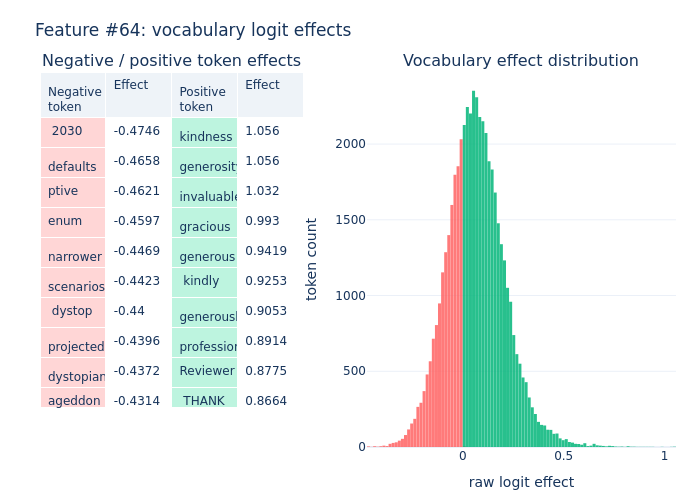

In [5]:
FEATURE_ID = 64

assert FEATURE_ID in effect.topk(5).indices.tolist(), (
    "feature 64 fell out of the top 5; re-read the table above and pick again"
)

logit_fig = plot_sae_feature_logit_effects(
    FEATURE_ID,
    decoder=decoder,
    unembedding=unembedding,
    token_labels=[
        model.tokenizer.decode([i]) for i in range(model.tokenizer.vocab_size)
    ],
    token_ids=list(range(model.tokenizer.vocab_size)),
    title=f"Feature #{FEATURE_ID}: vocabulary logit effects",
)
save_figure(logit_fig, f"{OUTPUT_DIR}/plots/feature_logit_effects.png")
logit_fig

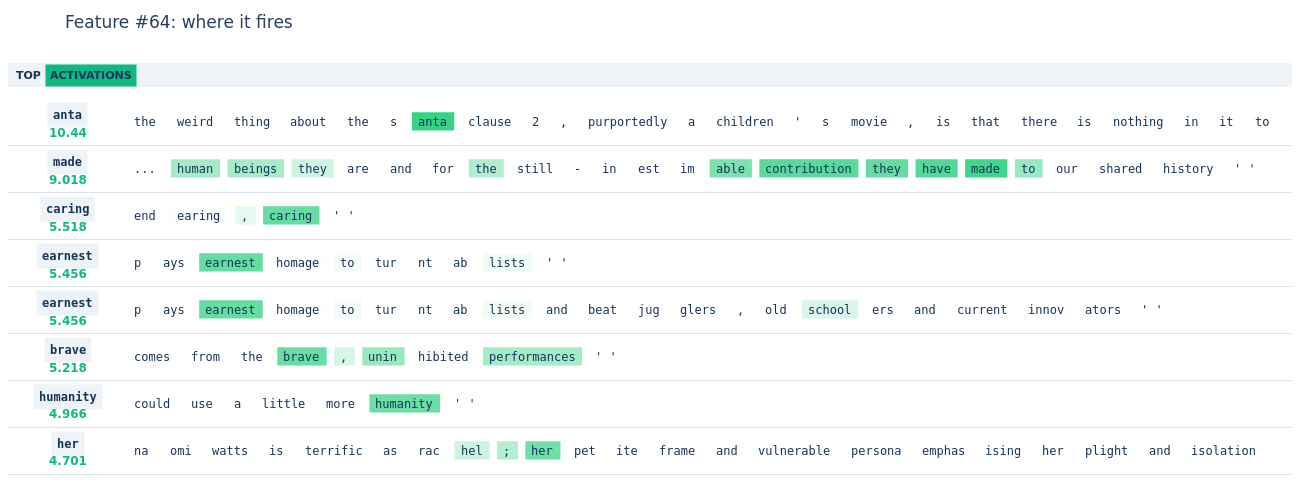

In [6]:
token_fig = plot_sae_token_activations(
    activations=activations,
    token_ids=tokens,
    attention_mask=record.attention_mask,
    feature_id=FEATURE_ID,
    decode_token=lambda token_id: model.tokenizer.decode([int(token_id)]),
    bos_token_id=model.tokenizer.bos_token_id,
    num_examples=8,
    title=f"Feature #{FEATURE_ID}: where it fires",
)
save_figure(token_fig, f"{OUTPUT_DIR}/plots/feature_token_activations.png")
token_fig

## What next

- [`sae_features.ipynb`](sae_features.ipynb) introduces the logit lens on a decoder direction that this notebook leans on.
- [`probing.ipynb`](probing.ipynb) asks the same question of raw activations rather than SAE features.